# Grover's Search Algorithm: Subset‑Sum Problem

**Author:** Phabel Antonio López Delgado, BSc.

Grover's algorithm provides a quadratic speedup for unstructured search problems. In this notebook, we apply Grover's algorithm to find which subsets of a given set of numbers sum to a target value (the subset‑sum problem). The algorithm uses a quantum oracle that marks the correct subsets by flipping their phase, and a diffusion operator that amplifies the amplitude of marked states.

**Key Concepts Covered:**
- Grover's search algorithm.
- Quantum oracle construction for a specific problem.
- Diffusion operator (inversion about the mean).
- Optimal number of iterations.
- Measurement and interpretation.

**Key Techniques & Libraries:**
- `qiskit` – quantum circuit construction.
- `qiskit-aer` – simulation backends.
- `matplotlib` – plotting histograms.

**Objective:**
To demonstrate Grover's algorithm on a concrete problem and understand its behaviour.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import random

# Configuration
CONFIG = {
    "shots": 1024,
    "random_seed": 42,
}

np.random.seed(CONFIG["random_seed"])
random.seed(CONFIG["random_seed"])

# Initialise simulator
qasm_sim = Aer.get_backend('qasm_simulator')

print("Configuration loaded.")
print(f"Simulator: {qasm_sim.name}")
print(f"Shots: {CONFIG['shots']}")

Configuration loaded.
Simulator: qasm_simulator
Shots: 1024


## 1. Problem Definition

We define a set of numbers and a target sum. We want to find all subsets that sum to the target. The number of qubits equals the number of elements in the set (each qubit represents whether that element is included in the subset).

In [2]:
# Define the problem
numbers = [1, 2, 3]
target_sum = 3
n_qubits = len(numbers)

print(f"Numbers: {numbers}")
print(f"Target sum: {target_sum}")
print(f"Number of qubits: {n_qubits}")

Numbers: [1, 2, 3]
Target sum: 3
Number of qubits: 3


## 2. Oracle Construction

The oracle flips the phase of the basis states that correspond to subsets whose sum equals the target. It does so by checking each possible subset (looping over all 2ⁿ states) and applying a multi‑controlled Z gate if the sum matches. This approach is educational but not scalable; for larger problems, more efficient oracle constructions exist.

**Note:** The oracle uses X gates to flip control qubits that need to be controlled on |0⟩, then applies a multi‑controlled Z, and undoes the flips.

In [3]:
def construct_oracle(qr, numbers, target_sum):
    """
    Construct a phase oracle that flips the phase of basis states whose subset sum equals the target.
    
    Args:
        qr (QuantumRegister): The quantum register for the qubits.
        numbers (list): The set of numbers.
        target_sum (int): The target sum.
    
    Returns:
        QuantumCircuit: The oracle circuit.
    """
    n = len(qr)
    oracle = QuantumCircuit(qr)  # Use the same quantum register
    
    # Loop over all basis states
    for i in range(2**n):
        binary_state = format(i, f'0{n}b')  # e.g., '001'
        subset_elements = [numbers[j] for j, bit in enumerate(binary_state) if bit == '1']
        if sum(subset_elements) == target_sum:
            # This state is a solution; flip its phase
            # Build a multi-controlled Z gate with controls on the appropriate qubits
            # First, apply X gates to qubits that should be controlled on |0⟩
            controls = []
            for j, bit in enumerate(binary_state):
                if bit == '1':
                    controls.append(qr[j])
                else:
                    oracle.x(qr[j])
                    controls.append(qr[j])
            # Apply multi-controlled Z using Hadamard and multi-controlled X
            # We'll use the last qubit as the target for the MCX, but we need to apply H before and after
            oracle.h(qr[-1])
            # MCX on all but the last qubit, targeting the last
            oracle.mcx(controls[:-1], qr[-1])
            oracle.h(qr[-1])
            # Undo the X gates for qubits controlled on |0⟩
            for j, bit in enumerate(binary_state):
                if bit == '0':
                    oracle.x(qr[j])
    
    return oracle

## 3. Quantum Fourier Transform (QFT) and Diffusion Operator

The diffusion operator amplifies the amplitude of marked states. In this implementation, we use the QFT‑based diffusion operator, which is a general approach to inversion about the mean. (An alternative, simpler diffusion uses Hadamard gates and a multi‑controlled Z.)

In [4]:
def qft(n):
    """
    Quantum Fourier Transform for n qubits.
    """
    qc_qft = QuantumCircuit(n)
    for qubit in range(n):
        qc_qft.h(qubit)
        for j in range(qubit + 1, n):
            qc_qft.cp(np.pi / 2**(j - qubit), j, qubit)
    return qc_qft

def inverse_qft(n):
    """
    Inverse Quantum Fourier Transform.
    """
    return qft(n).inverse()

def diffusion_operator(qr):
    """
    Diffusion operator using QFT (inversion about the mean).
    """
    n = len(qr)
    diff = QuantumCircuit(qr)
    
    # Step 1: Apply QFT
    diff.compose(qft(n), qubits=qr, inplace=True)
    
    # Step 2: Inversion about |0⟩ (apply H, X, multi-controlled Z, X, H)
    for qubit in range(n):
        diff.h(qr[qubit])
        diff.x(qr[qubit])
    # Multi-controlled Z: H on target, MCX, H
    diff.h(qr[-1])
    controls = list(qr[:-1])
    diff.mcx(controls, qr[-1])
    diff.h(qr[-1])
    for qubit in range(n):
        diff.x(qr[qubit])
        diff.h(qr[qubit])
    
    # Step 3: Apply inverse QFT
    diff.compose(inverse_qft(n), qubits=qr, inplace=True)
    
    return diff

## 4. Grover's Algorithm Circuit

We combine the oracle and diffusion operator into a full Grover circuit. The number of iterations is approximately \( \lfloor \frac{\pi}{4} \sqrt{2^n / M} \rfloor \), where \( M \) is the number of solutions. In this simple example, we have multiple solutions (subsets summing to 3), so we will use a heuristic number of iterations based on the square root of the search space size.

In [5]:
def grover_circuit(qr, cr, oracle, diffusion, num_iterations):
    """
    Build the full Grover circuit.
    
    Args:
        qr: Quantum register.
        cr: Classical register.
        oracle: Oracle circuit.
        diffusion: Diffusion operator circuit.
        num_iterations: Number of Grover iterations.
    
    Returns:
        QuantumCircuit: The complete circuit.
    """
    n = len(qr)
    qc = QuantumCircuit(qr, cr)
    
    # Initialise superposition
    qc.h(qr)
    
    # Apply Grover iterations
    for _ in range(num_iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)
    
    # Measure
    qc.measure(qr, cr)
    
    return qc

## 5. Calculate Number of Iterations and Run

We calculate the number of iterations as \( \lfloor \frac{\pi}{4} \sqrt{2^n} \rfloor \) (assuming one solution; in practice, if there are multiple solutions, the optimal number changes, but this approximation works for demonstration). We then build and simulate the circuit.

In [6]:
# Number of solutions (in this example, we have multiple)
# For simplicity, we use the general formula for one solution
num_iterations = int(np.floor(np.pi / 4 * np.sqrt(2**n_qubits)))
print(f"Number of Grover iterations (approximate): {num_iterations}")

# Create registers
qr = QuantumRegister(n_qubits, 'q')
cr = ClassicalRegister(n_qubits, 'c')

# Build oracle and diffusion
oracle = construct_oracle(qr, numbers, target_sum)
diffusion = diffusion_operator(qr)

# Build full circuit
qc = grover_circuit(qr, cr, oracle, diffusion, num_iterations)

# Draw the circuit
try:
    fig = qc.draw('mpl')
    fig.savefig('grover_circuit.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
except Exception as e:
    print("Circuit drawing failed, falling back to text:")
    print(qc.draw(output='text'))

# Run simulation
compiled = transpile(qc, qasm_sim)
job = qasm_sim.run(compiled, shots=CONFIG["shots"])
counts = job.result().get_counts()

# Print and decode results
print(f"\nMeasurement results (bitstring -> counts):")
for bitstring, count in counts.items():
    # Convert bitstring to subset (qubit order: q0 corresponds to numbers[0], etc.)
    # Note: Qiskit's convention: bitstring is ordered from the most significant qubit (q_{n-1}) to the least (q0)
    # We'll reverse to match the order of numbers
    reversed_bits = bitstring[::-1]
    subset = [numbers[i] for i, bit in enumerate(reversed_bits) if bit == '1']
    subset_sum = sum(subset)
    print(f"{bitstring} -> subset {subset}, sum = {subset_sum}, counts = {count}")

Number of Grover iterations (approximate): 2
Circuit drawing failed, falling back to text:
     ┌───┐┌───┐     ┌───┐               ┌───┐                  ┌───┐  ┌───┐  »
q_0: ┤ H ├┤ X ├──■──┤ X ├────────────■──┤ H ├─■────────■───────┤ H ├──┤ X ├──»
     ├───┤├───┤  │  ├───┤            │  └───┘ │P(π/2)  │       ├───┤  └───┘  »
q_1: ┤ H ├┤ X ├──■──┤ X ├────────────■────────■────────┼───────┤ H ├─■───────»
     ├───┤├───┤┌─┴─┐├───┤┌───┐┌───┐┌─┴─┐┌───┐  ┌───┐   │P(π/4) └───┘ │P(π/2) »
q_2: ┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├──┤ X ├───■─────────────■───────»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘  └───┘                         »
c: 3/════════════════════════════════════════════════════════════════════════»
                                                                             »
«                              ┌───┐┌───┐                                   »
«q_0: ──────────────────────■──┤ X ├┤ H ├──────────────────────────■────────»
«     ┌───┐┌───┐            │  ├───┤├───┤ 

## 6. Visualisation and Interpretation

We plot the measurement histogram, showing the counts for each subset. The algorithm should amplify the amplitudes of the correct subsets (those summing to the target) so they appear more frequently than incorrect ones.

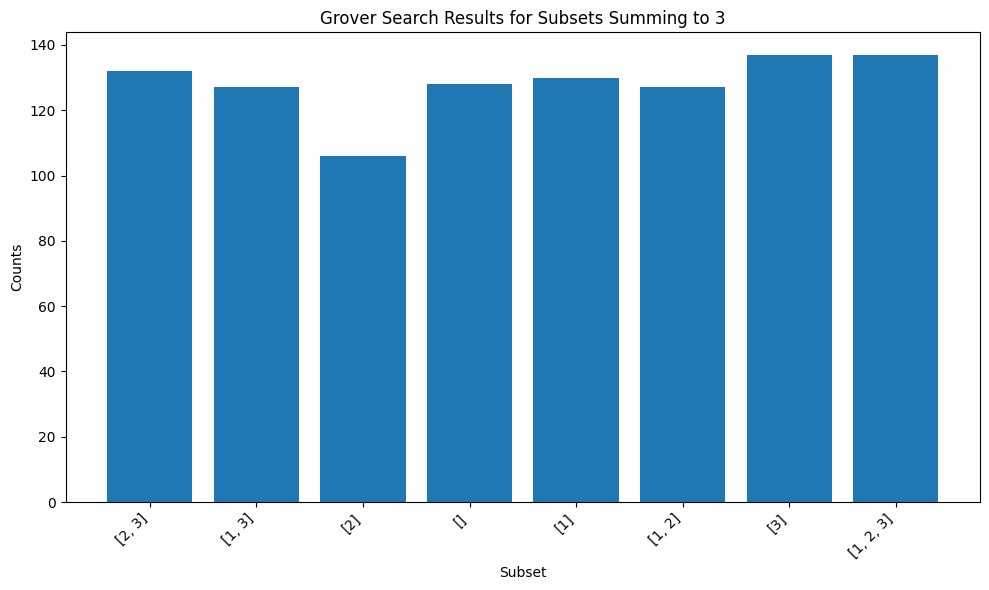

In [7]:
# Decode bitstrings for plotting
bitstrings = list(counts.keys())
counts_values = list(counts.values())
decoded_subsets = []
for bitstring in bitstrings:
    reversed_bits = bitstring[::-1]
    subset = [numbers[i] for i, bit in enumerate(reversed_bits) if bit == '1']
    decoded_subsets.append(str(subset))  # Convert to string for labelling

plt.figure(figsize=(10, 6))
plt.bar(range(len(decoded_subsets)), counts_values, tick_label=decoded_subsets)
plt.xlabel('Subset')
plt.ylabel('Counts')
plt.title(f'Grover Search Results for Subsets Summing to {target_sum}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('grover_histogram.png')
plt.show()
plt.close('all')

## 7. Analysis and Discussion

**Expected behaviour:**  
The algorithm should find the subsets that sum to the target with high probability. In this example, the target sum is 3, and the subsets are `[3]` and `[1,2]`. Both should have high counts.

**Why does it work?**  
Grover's algorithm uses amplitude amplification: the oracle marks the solution states by flipping their phase, and the diffusion operator reflects the amplitudes about the mean, increasing the probability of measuring marked states.

**Limitations:**  
- The oracle construction here is brute‑force; for large sets, it becomes infeasible.
- The number of iterations depends on the number of solutions; for multiple solutions, the optimal number is slightly different.
- This implementation uses QFT for diffusion, which is more resource‑intensive than the standard diffusion (which uses only Hadamards and a multi‑controlled Z).

**Key takeaway:**  
Grover's algorithm provides a quadratic speedup over classical search, making it useful for problems where the search space is large and there is no structure to exploit classically.

## Summary

**Accomplished:**
- Implemented Grover's algorithm for the subset‑sum problem.
- Built a phase oracle and a diffusion operator.
- Visualised circuit and measurement results.
- Observed amplification of correct subsets.

**Key Insights:**
- Grover's algorithm is a fundamental quantum search algorithm.
- The oracle encodes the problem‑specific information.
- The diffusion operator amplifies the amplitude of marked states.
- The algorithm demonstrates quadratic speedup.

**Next Steps:**
- Explore the Quantum Fourier Transform and its applications.
- Implement phase estimation.
- Run the algorithm on real quantum hardware.